In [1]:
from inception.instruments import TensorExtensionInterpolator, AutoCallableNoteChebyshev
from inception.instruments.constant_parameters import NOTES_PARAMETERS

import numpy as np
import pandas as pd
from inception.instruments.constant_parameters import NOTES_PARAMETERS
from inception.instruments import ReferenceMultiIndexReturnSimulator, MultiAssetAutoCallableNote

import time
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sb
import matplotlib.pyplot as plt

In [26]:
stock_price=[382.82, 494.08, 142.86]
evaluate_date='2025-02-13'

start_date = '2024-02-14'
issued_price = [382.82, 494.08, 142.86]
index_vol = [0.16, 0.16, 0.16]
risk_free_rate = 0.05

In [27]:
interpolator = TensorExtensionInterpolator('./autocallable_database/')
parameters = NOTES_PARAMETERS['CIBC Multi Assets One']

notes_c = AutoCallableNoteChebyshev(start_date=start_date,
                                    evaluate_date=evaluate_date,
                                    underlying_names=['A', 'B', 'C'],
                                    stock_price=stock_price,
                                    vol=index_vol,
                                    issue_price=issued_price,
                                    note_interpolator=interpolator,
                                    valuation_dates=parameters['valuation dates'],
                                    call_dates=parameters['call dates'],
                                    coupon_payment_dates=parameters['coupon dates'],
                                    coupon_barrier=parameters['coupon barrier'],
                                    call_barrier=parameters['call barrier'],
                                    principal_barrier=parameters['principal barrier'],
                                    coupon_amount=parameters['coupon amount'],
                                    free_rate=risk_free_rate)

t1 = time.time()
print('Value :', notes_c.value)
print('Delta :', notes_c.delta)
print('Gamma :', notes_c.gamma)
print(f'Total time: {time.time() - t1}')

Value : 103.36235802313945
Delta : A: -0.014519037400446496, B: -0.010880048099428686, C: -0.08033439744653845
Gamma : A: 0.0002017856744734632, B: 0.00013063217209021298, C: 0.0030477062468230215
Total time: 0.0010006427764892578


In [7]:
corr_matrix = np.array(
    [[1.        , 0.96432854, 0.80799003],
    [0.96432854, 1.        , 0.8267037 ],
    [0.80799003, 0.8267037 , 1.        ]]
)

path_num = 100_000
d_s = 0.02
simulator = ReferenceMultiIndexReturnSimulator(issued_price, stock_price, risk_free_rate, index_vol, corr_matrix, d_s)
notes = MultiAssetAutoCallableNote(evaluate_date,
                                   ['A', 'B', 'C'],
                                   simulator, 
                                   parameters['valuation dates'],
                                   parameters['coupon dates'],
                                   parameters['call dates'],
                                   coupon_barrier=parameters['coupon barrier'],
                                   call_barrier=parameters['call barrier'],
                                   principal_barrier=parameters['principal barrier'],
                                   coupon_amount=parameters['coupon amount'],
                                   free_rate=risk_free_rate,
                                   n_paths=path_num)
t1 = time.time()
print('Value :', notes.value)
print('Delta :', notes.delta)
print('Gamma :', notes.gamma)
print(f'Total time: {time.time() - t1}')

Value : 103.07301630815302
Delta : A: -0.033971944959254055, B: -0.025522241652432276, C: -0.10013463393403835
Gamma : A: 0.008403918598758673, B: 0.005135792568964125, C: 0.049579681783530026
Total time: 4.939003944396973


Auto Call probability: 0.883805


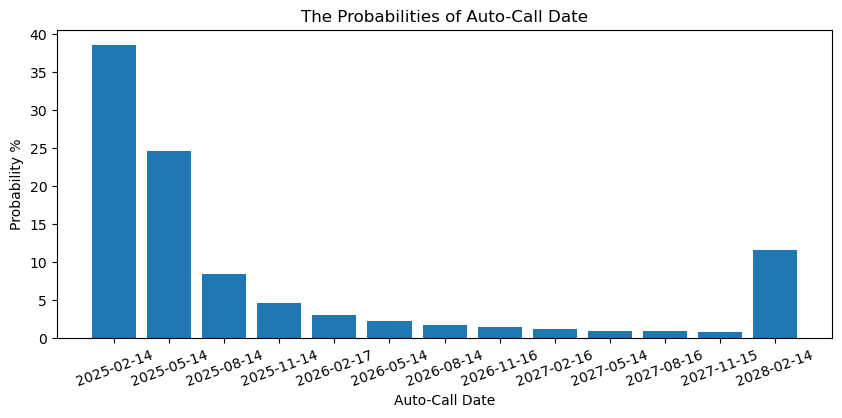

In [5]:
from collections import Counter
print(f'Auto Call probability: {notes.call_ratio}')
notes.termination_date_list.sort()
date_count = Counter(notes.termination_date_list)

y = [n / (path_num * 2) * 100 for n in date_count.values()]
plt.figure(figsize=(10, 4))
plt.bar(range(len(date_count)), y)
_ = plt.xticks(range(len(date_count)), date_count.keys(), rotation  =20)
plt.title('The Probabilities of Auto-Call Date')
_ = plt.ylabel('Probability %')
_ = plt.xlabel('Auto-Call Date')

In [3]:
def autocallable_note_pricer(x: list, additonal_data = None):
    """
    The Autocallable Notes pricer function wrapper, (adapts the original function signature to the signature expected by MoCaX)
    :param x: [stock A price, stock B price, stock C price, days after the start date]
    :param additional_data: extra parameters required by MoCaX
    """
    
    start_date = '2024-02-14'
    # Input parameters:
    spot_price = np.array(x[:3])
    eval_date = pd.Timestamp(start_date) + pd.Timedelta(days=x[3])
    
    corr_matrix = np.array(
        [[1.        , 0.96432854, 0.80799003],
        [0.96432854, 1.        , 0.8267037 ],
        [0.80799003, 0.8267037 , 1.        ]]
    )
    issued_price = [382.82, 494.08, 142.86]
    index_vol = [0.16, 0.16, 0.16]
    risk_free_rate = 0.05
    path_num = 100_000
    d_s = 0.02
    parameters = NOTES_PARAMETERS['CIBC Multi Assets One']
    simulator = ReferenceMultiIndexReturnSimulator(issued_price, spot_price, risk_free_rate, index_vol, corr_matrix, d_s)
    notes = MultiAssetAutoCallableNote(eval_date,
                                       simulator, 
                                       parameters['valuation dates'],
                                       parameters['coupon dates'],
                                       parameters['call dates'],
                                       coupon_barrier=parameters['coupon barrier'],
                                       call_barrier=parameters['call barrier'],
                                       principal_barrier=parameters['principal barrier'],
                                       coupon_amount=parameters['coupon amount'],
                                       free_rate=risk_free_rate,
                                       n_paths=path_num)
    
    return notes.value

In [87]:
func = lambda x: np.random.uniform(x * 0.2, x * 1.5)
value_m = []
value_p = []
issued_price = [382.82, 494.08, 142.86]
date_range = pd.bdate_range('2024-09-14', '2028-02-13')
start_date = pd.Timestamp('2024-02-14')

for _ in range(1000):
    date = np.random.choice(date_range)
    x = [func(d) for d in issued_price] + [(date - start_date).days]
    notes_c = AutoCallableNoteChebyshev(start_date=start_date,
                                        evaluate_date=date,
                                        underlying_name=['A', 'B', 'C'],
                                        stock_price=x[:3],
                                        vol=[0.16, 0.16, 0.16],
                                        issue_price=[382.82, 494.08, 142.86],
                                        note_interpolator=interpolator,
                                        valuation_dates=parameters['valuation dates'],
                                        call_dates=parameters['call dates'],
                                        coupon_payment_dates=parameters['coupon dates'],
                                        coupon_barrier=parameters['coupon barrier'],
                                        call_barrier=parameters['call barrier'],
                                        principal_barrier=parameters['principal barrier'],
                                        coupon_amount=parameters['coupon amount'],
                                        free_rate=0.05)

    value_m.append(notes_c.value)
    value_p.append(autocallable_note_pricer(x))

Maximum error: 9.93558
Mean error: 0.57975


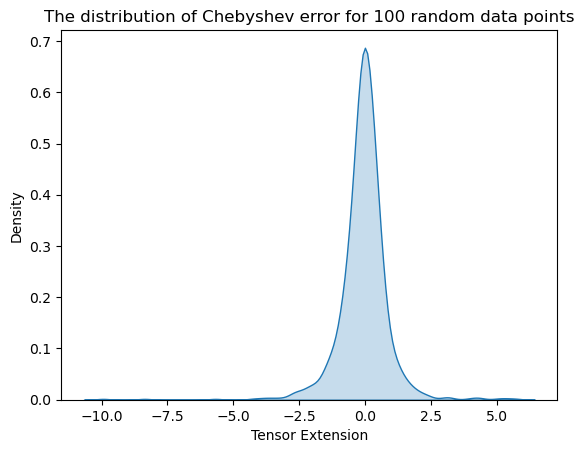

In [88]:
error_2 = (np.array(value_p) - np.array(value_m)) / np.array(value_p) * 100
sb.kdeplot(error_2,fill=True)
plt.title('The distribution of Chebyshev error for 100 random data points')
plt.xlabel('Tensor Extension')

# -- Empirical error
error_sup = max(abs(error_2))
error_mean = abs(error_2).mean()

print(f"Maximum error: {error_sup:.5f}")
print(f"Mean error: {error_mean:.5f}")

In [6]:
date_range = pd.bdate_range('2024-09-14', '2028-02-13')

issued_price = [382.82, 494.08, 142.86]

price_percentage = np.arange(0.2, 1.2, 0.05)
values_mocax = []
values_func = []
start_date = pd.Timestamp('2024-02-14')
i = 0
for p in tqdm(price_percentage):
    values_mocax.append([])
    values_func.append([])
    for d in date_range:
        notes_c = AutoCallableNoteChebyshev(start_date='2024-02-14',
                                    evaluate_date=d,
                                    underlying_name=['A', 'B', 'C'],
                                    stock_price=[price * p for price in issued_price],
                                    vol=[0.16, 0.16, 0.16],
                                    issue_price=[382.82, 494.08, 142.86],
                                    note_interpolator=interpolator,
                                    valuation_dates=parameters['valuation dates'],
                                    call_dates=parameters['call dates'],
                                    coupon_payment_dates=parameters['coupon dates'],
                                    coupon_barrier=parameters['coupon barrier'],
                                    call_barrier=parameters['call barrier'],
                                    principal_barrier=parameters['principal barrier'],
                                    coupon_amount=parameters['coupon amount'],
                                    free_rate=0.05)
        x = [price * p for price in issued_price] + [(d - start_date).days]
        
        values_mocax[i].append(notes_c.value)
#         values_func[i].append(autocallable_note_pricer(x))
    i += 1

100%|██████████████████████████████████████████████████████████████████████████████████| 20/20 [01:57<00:00,  5.88s/it]


C:\Users\TY482JM\AppData\Local\Temp\ipykernel_26728\3600550708.py:5: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax = plt.subplot(121, projection='3d')


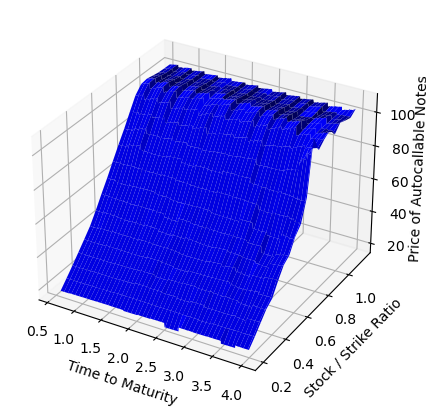

In [7]:
fig = plt.figure(figsize =(15, 5))

plt.subplot(121)
# ax = plt.axes(projection ='3d')
ax = plt.subplot(121, projection='3d')

times = [(d - pd.Timestamp('2024-02-14')).days / 365 for d in date_range]

x1,y1= np.meshgrid(times, price_percentage)

ax.plot_surface(x1, y1, np.array(values_mocax), color='blue')


ax.set_xlabel('Time to Maturity')
ax.set_ylabel('Stock / Strike Ratio')
ax.set_zlabel('Price of Autocallable Notes', rotation=90)
ax.zaxis.labelpad=-0.7

C:\Users\TY482JM\AppData\Local\Temp\ipykernel_37368\3755030170.py:5: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax = plt.subplot(121, projection='3d')


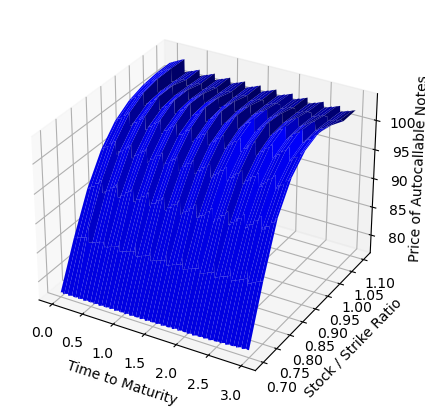

In [17]:
fig = plt.figure(figsize =(15, 5))

plt.subplot(121)
# ax = plt.axes(projection ='3d')
ax = plt.subplot(121, projection='3d')

times = [(d - pd.Timestamp('2024-02-14')).days / 365 for d in date_range]

x1,y1= np.meshgrid(times, price_percentage)

ax.plot_surface(x1, y1, np.array(values_func), color='blue')


ax.set_xlabel('Time to Maturity')
ax.set_ylabel('Stock / Strike Ratio')
ax.set_zlabel('Price of Autocallable Notes', rotation=90)
ax.zaxis.labelpad=-0.7

C:\Users\TY482JM\AppData\Local\Temp\ipykernel_37368\2807219642.py:5: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax = plt.subplot(121, projection='3d')


Text(0.5, 0, 'The error(%)')

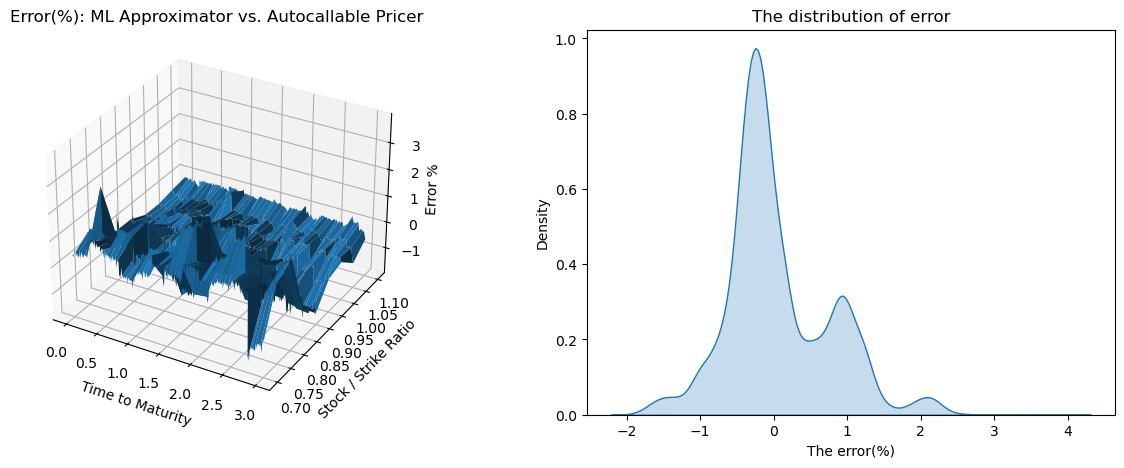

In [16]:
fig = plt.figure(figsize =(15, 5))

plt.subplot(121)
# ax = plt.axes(projection ='3d')
ax = plt.subplot(121, projection='3d')


x1,y1= np.meshgrid(times, price_percentage)
error = (np.array(values_func) - np.array(values_mocax)) / np.array(values_func) * 100

ax.plot_surface(x1, y1, error)
ax.set_title('Error(%): ML Approximator vs. Autocallable Pricer')


ax.set_xlabel('Time to Maturity')
ax.set_ylabel('Stock / Strike Ratio')
ax.set_zlabel('Error %', rotation=90)
ax.zaxis.labelpad=-0.7

ax2 = plt.subplot(122)
sb.kdeplot(error.flatten(),fill=True)
plt.title('The distribution of error')
plt.xlabel('The error(%)')

In [12]:
pd.DataFrame(error).T.describe()

,0,1,2,3,4,5,6,7,8
count,783.000000,783.000000,783.000000,783.000000,783.000000,783.000000,783.000000,783.000000,783.000000
mean,0.655253,1.117243,0.431825,-0.274512,-0.397927,-0.298151,-0.339887,-0.348981,-0.149394
std,0.588016,0.550332,0.760724,0.529931,0.555296,0.340349,0.165224,0.196243,0.096891
min,-1.518597,0.070269,-1.162707,-1.777119,-1.859388,-1.269489,-1.443789,-1.027364,-0.533032
25%,0.471585,0.830476,-0.052860,-0.700782,-0.533852,-0.491918,-0.426303,-0.425267,-0.186546
50%,0.806278,0.946663,0.438116,-0.202652,-0.230172,-0.309604,-0.328278,-0.345236,-0.139187
75%,1.030171,1.251863,1.005149,0.132948,-0.004991,-0.043206,-0.238602,-0.267957,-0.094431
max,1.565095,3.954677,2.171223,0.855843,0.516746,0.405001,0.022135,0.575626,0.179785
